## Deep Learning

### Chapter 4: The Nine-Step Workflow of Neural Network

This notebook demonstrates a complete workflow for building and training a simple deep learning model using Keras for image classification on the MNIST dataset. We covered:

1.  **Loading and Exploring Data**: Importing the MNIST dataset and understanding its structure.
2.  **Data Preparation**: Reshaping and normalizing image data for model input.
3.  **Model Building**: Constructing a sequential neural network with Dense layers and ReLU/Softmax activation functions.
4.  **Model Compilation**: Configuring the model with an optimizer, loss function, and evaluation metrics.
5.  **Training and Validation**: Fitting the model to training data, monitoring performance with a validation set, and plotting learning curves.
6.  **Optimal Epoch Selection**: Identifying the best training duration to prevent overfitting.
7.  **Model Retraining**: Training the final model with the optimal epoch count.
8.  **Evaluation**: Assessing the model's performance on a dedicated test set.
9.  **Prediction**: Using the trained model to predict labels for new images.

#### Step 1. Load the Data

Here, we load the MNIST dataset, which is a collection of handwritten digits. It's split into training and testing sets, each containing images and their corresponding labels. We display the shapes and a sample of the labels to understand the data structure.

#### Step 2. Prepare the Data

Here, we reshape the image data from 2D arrays (28x28 pixels) into 1D vectors (784 pixels) to be compatible with our neural network. We also normalize the pixel values by dividing them by 255.0, scaling them to a range between 0 and 1. This helps in faster and more stable training of the model.

**Loading the MNIST Dataset**

This section deals with loading the MNIST dataset, which is a collection of handwritten digits, into our environment. The dataset is split into training and testing sets, providing images and their corresponding labels for model development and evaluation.

In [1]:
# Load the MNIST Dataset
from keras.datasets import mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

print("Train Images length:", len(train_images))
print("Train Labels length:", len(train_labels))
print("Test Images length:", len(test_images))
print("Test Labels length:", len(test_labels))

print("\nTrain Images shape:", train_images.shape)
print("Train Labels shape:", train_labels.shape)
print("Test Images shape:", test_images.shape)
print("Test Labels shape:", test_labels.shape)

print(train_labels[:10])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train Images length: 60000
Train Labels length: 60000
Test Images length: 10000
Test Labels length: 10000

Train Images shape: (60000, 28, 28)
Train Labels shape: (60000,)
Test Images shape: (10000, 28, 28)
Test Labels shape: (10000,)
[5 0 4 1 9 2 1 3 1 4]


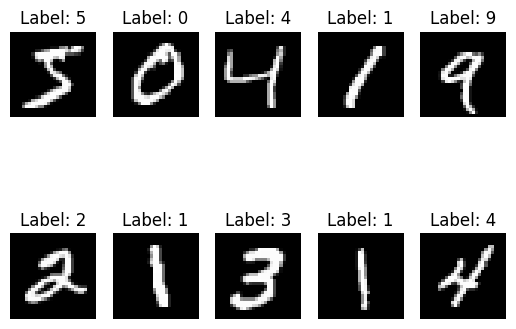

In [2]:
import matplotlib.pyplot as plt

# Display images with matplotlib
for i in range(1, 2):
    for j in range(10):
        plt.subplot(i + 1, 5, j + 1)
        plt.imshow(train_images[j], cmap='gray')
        plt.title(f"Label: {train_labels[j]}")
        plt.axis('off')

plt.show()

**Preparing the MNIST Data**

In this step, we prepare the MNIST image data for our neural network. This involves two main transformations:

1.  **Reshaping**: The original images are 28x28 pixel 2D arrays. We reshape them into 1D vectors of 784 pixels (28 * 28 = 784). This flattening is necessary because our dense neural network layers expect a 1D input.
2.  **Normalization**: The pixel values in grayscale images range from 0 to 255. We normalize these values by dividing them by 255.0. This scales the pixel intensities to a range between 0 and 1, which helps the neural network train more efficiently and stably.

In [3]:
# Reshape image from (28, 28) → (784,)
train_images = train_images.reshape((60000, 28 * 28))
test_images = test_images.reshape((10000, 28 * 28))

print("Train Images Shape:", train_images.shape)
print("Test Images Shape:", test_images.shape)

Train Images Shape: (60000, 784)
Test Images Shape: (10000, 784)


In [4]:
# Normalize data
train_images = train_images.astype("float32") / 255
test_images = test_images.astype("float32") / 255

#### Step 3. Build the Model

This section focuses on constructing the neural network architecture. We define the layers, specifying their number of units and activation functions (ReLU for hidden layers, Softmax for the output layer), which are crucial for the model's learning capabilities.

**Neural Network**

A neural network is a series of algorithms that endeavors to recognize underlying relationships in a set of data through a process that mimics the way the human brain operates. It consists of layers of interconnected nodes, or 'neurons', that process information.

**Activation Functions**

Activation functions introduce non-linearity into the neural network, allowing it to learn complex patterns. Common activation functions include ReLU (Rectified Linear Unit) for hidden layers and Softmax for output layers in multi-class classification problems.

**Model Structure**

The model structure defines how the layers of the neural network are connected. In Keras, a `Sequential` model is a linear stack of layers, suitable for simple models where the output of one layer feeds directly into the input of the next.

In [5]:
from tensorflow import keras
from tensorflow.keras import layers

# Build the model
hidden_layer1 = layers.Dense(512, activation="relu")
hidden_layer2 = layers.Dense(256, activation="relu")
output_layer = layers.Dense(10, activation="softmax")

model = keras.Sequential([hidden_layer1, hidden_layer2,
                          output_layer])

#### Step 4. Compile the Model

In this step, we configure the model for training. We specify the optimizer ('rmsprop'), which adjusts the model's weights during training, the loss function ('sparse_categorical_crossentropy'), which measures the error between predictions and true labels, and the metrics ('accuracy') to monitor performance.

In [6]:
# Compile the model
model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

**The Flow of a Neural Network**

The training process of a neural network generally follows these steps:
1.  **Forward Pass**: Input data is fed through the network to generate predictions.
2.  **Loss (Measuring Error)**: The difference between predictions and true labels is calculated.
3.  **Backpropagation**: The error is propagated backward through the network to determine how much each weight contributed to the error.
4.  **Optimizer (Fixing the Mistakes)**: Weights are adjusted based on the error gradients to minimize the loss.

#### Step 5. Train and Validate the Model

This step involves training the neural network on the prepared data. We define key training parameters:

1.  **Epoch** — One Full Pass Through the Data: An epoch is when the entire training dataset is passed forward and backward through the neural network once.
2.  **Batch Size** — How Much the Model Sees at Once: This determines the number of training examples utilized in one iteration.
3.  **Validation Data**: A portion of the training data is set aside for validation to monitor the model's performance on unseen data during training and prevent overfitting.

In [7]:
# Fit the model
model.fit(train_images, train_labels, epochs=20, batch_size=128, validation_split=0.2)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9208 - loss: 0.2629 - val_accuracy: 0.9634 - val_loss: 0.1238
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9699 - loss: 0.0963 - val_accuracy: 0.9724 - val_loss: 0.0893
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9815 - loss: 0.0604 - val_accuracy: 0.9758 - val_loss: 0.0848
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9853 - loss: 0.0431 - val_accuracy: 0.9747 - val_loss: 0.0938
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9905 - loss: 0.0297 - val_accuracy: 0.9643 - val_loss: 0.1257
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9923 - loss: 0.0236 - val_accuracy: 0.9773 - val_loss: 0.0942
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9949 - loss: 0.0151 - val_accuracy: 0.9787 - val_loss: 0.0943
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9961 - loss: 0.0121 - val_accuracy: 0.

#### Step 6. Fit the Model and Monitor Performance

Here, we fit the model to the training data. The `model.fit()` function starts the training process, iteratively adjusting the model's weights based on the loss function and optimizer. We monitor the training and validation loss and accuracy during this process to assess how well the model is learning and generalizing.

In [8]:
# Record the model in history
history = model.history

# Print the metrics
print("Train Loss:", history.history["loss"][-1])
print("Validation Loss:", history.history["val_loss"][-1])
print("Train Accuracy:", history.history["accuracy"][-1])
print("Validation Accuracy:", history.history["val_accuracy"][-1])

Train Loss: 1.733649696689099e-05
Validation Loss: 0.11612799018621445
Train Accuracy: 1.0
Validation Accuracy: 0.9825000166893005


#### Step 7. Select the Best Model (Epoch Selection)

After training, we analyze the learning curves (training loss/accuracy vs. validation loss/accuracy) to identify the optimal number of epochs. The goal is to find the point where the model performs best on the validation set, balancing between underfitting and overfitting. This helps in selecting the most generalized model.

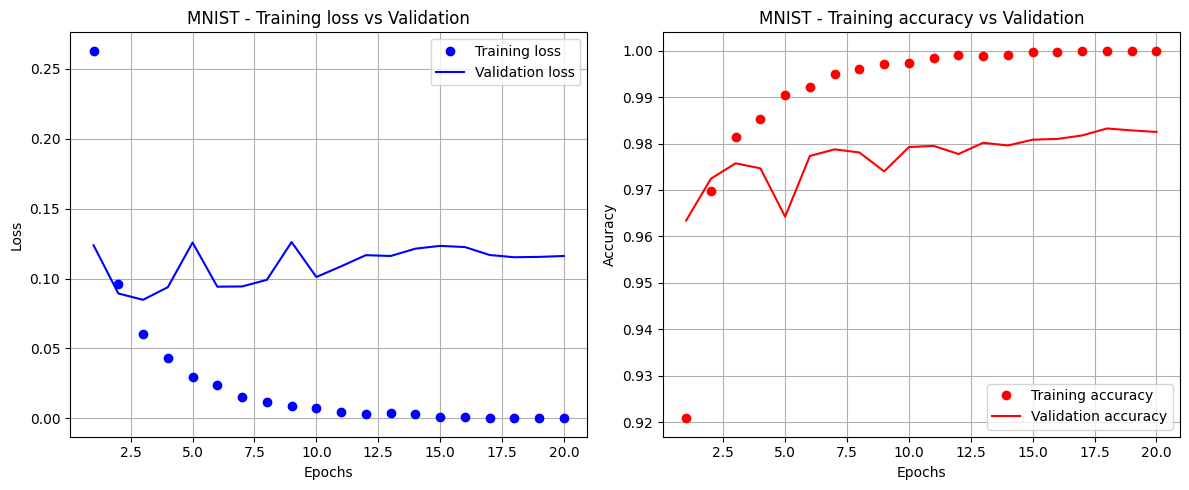

In [9]:
# Plot the Train Loss, Validation Loss, Train Accuracy, Validation Accuracy
import matplotlib.pyplot as plt


loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(1, len(loss) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(epochs, loss, 'bo', label='Training loss')
ax[0].plot(epochs, val_loss, 'b', label='Validation loss')
ax[0].set_title('MNIST - Training loss vs Validation')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(epochs, acc, 'ro', label='Training accuracy')
ax[1].plot(epochs, val_acc, 'r', label='Validation accuracy')
ax[1].set_title('MNIST - Training accuracy vs Validation')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

#### Step 8. Evaluate on the Test Set

In this crucial step, we evaluate the trained model's performance on a completely unseen test dataset. This provides an unbiased assessment of how well the model generalizes to new data. We calculate metrics such as test accuracy and test loss to quantify the model's effectiveness.

In [10]:
import numpy as np

# Evaluate on test set
y_pred = model.predict(test_images)
y_pred = np.argmax(y_pred, axis=1)
print("Test Accuracy:", np.mean(y_pred == test_labels))
print("Test Loss:", model.evaluate(test_images, test_labels)[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test Accuracy: 0.9845
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9845 - loss: 0.0955
Test Loss: 0.09547922760248184


#### Step 9. Prediction

Finally, we use the trained and optimized model to make predictions on new, unseen images. We demonstrate this by predicting the labels for a small set of test images and visually comparing the model's predictions with the true labels. This provides a qualitative understanding of the model's predictive capabilities.

Prediction: 7, True Label: 7
Prediction: 2, True Label: 2
Prediction: 1, True Label: 1
Prediction: 0, True Label: 0
Prediction: 4, True Label: 4
Prediction: 1, True Label: 1
Prediction: 4, True Label: 4
Prediction: 9, True Label: 9
Prediction: 5, True Label: 5
Prediction: 9, True Label: 9


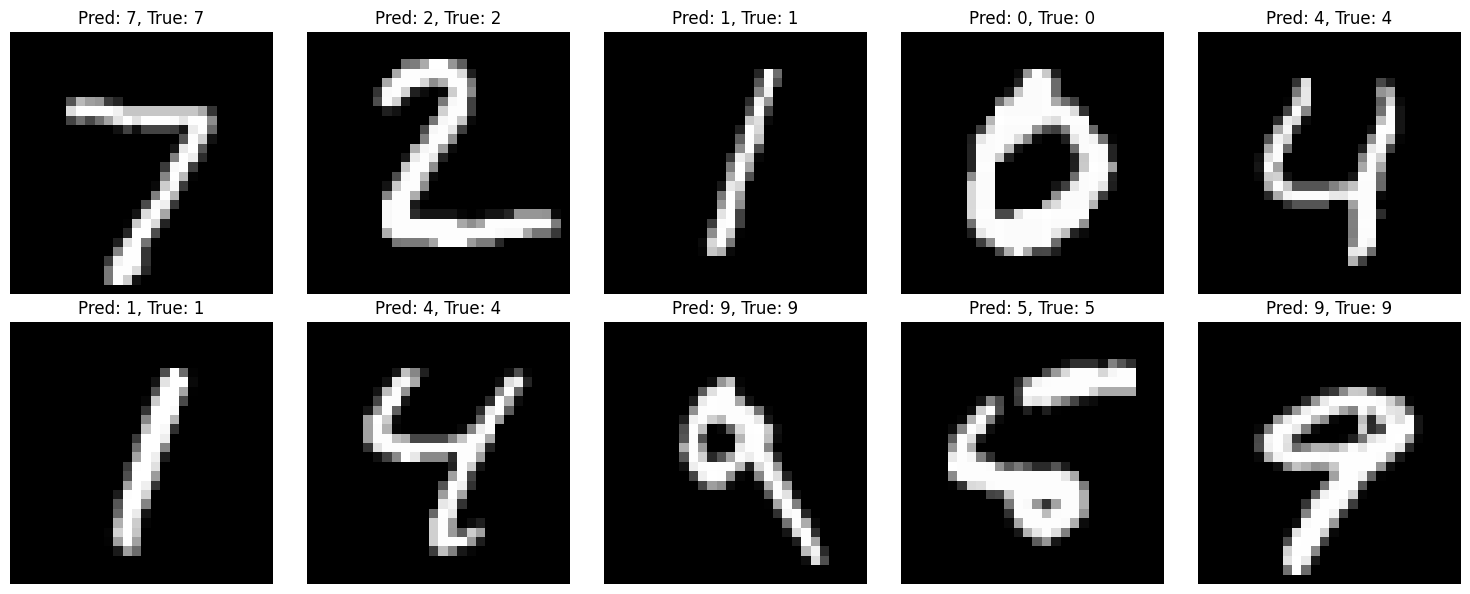

In [11]:
# Predict on new images
import numpy as np
import matplotlib.pyplot as plt

# Get the first 10 images from the test set
new_images = test_images[:10]
new_labels = test_labels[:10]

# Create a figure and a 2x5 subplot grid
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten() # Flatten the 2x5 array of axes for easy iteration

# Predict for each image and display the result
for i in range(10):
    current_image = new_images[i]
    true_label = new_labels[i]
    # Reshape to match the model's input shape (1, 28 * 28)
    image_input = current_image.reshape(1, 28 * 28)
    prediction = model.predict(image_input, verbose=0)
    predicted_label = prediction[0].argmax()

    print(f"Prediction: {predicted_label}, True Label: {true_label}")

    # Display the image in the subplot
    axes[i].imshow(current_image.reshape(28, 28), cmap='gray')
    axes[i].set_title(f"Pred: {predicted_label}, True: {true_label}")
    axes[i].axis('off')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

#### Retraining the model

After selecting the optimal epoch from the validation curves, we retrain the model on the full training dataset (or a larger portion) using that optimal number of epochs. This ensures that the model learns from as much data as possible while avoiding overfitting, leading to a more robust final model. The model is then re-evaluated on the test set to confirm its performance.

In [12]:
# Retrain the model with the optimal epoch
model = keras.Sequential([hidden_layer1, hidden_layer2,
                          output_layer])
model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
# Based on the plot, we choose epoch=4
model.fit(train_images, train_labels, epochs=4, batch_size=128, validation_split=0.2)
# Compute loss
y_pred = model.predict(test_images)
y_pred = np.argmax(y_pred, axis=1)
print("Test Accuracy:", np.mean(y_pred == test_labels))
print("Test Loss:", model.evaluate(test_images, test_labels)[0])

Epoch 1/4
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 1.0000 - loss: 1.5186e-05 - val_accuracy: 0.9826 - val_loss: 0.1169
Epoch 2/4
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 1.0000 - loss: 1.3745e-05 - val_accuracy: 0.9826 - val_loss: 0.1174
Epoch 3/4
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 1.0000 - loss: 1.2508e-05 - val_accuracy: 0.9827 - val_loss: 0.1179
Epoch 4/4
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 1.0000 - loss: 1.1537e-05 - val_accuracy: 0.9825 - val_loss: 0.1184
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test Accuracy: 0.9843
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9843 - loss: 0.0975
Test Loss: 0.0974789708852768
